# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test9 builder

Notebook equivalent of `tests/6_mceq/test9_builder.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `mceq` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `mceq` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test9_builder"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "6_mceq" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\6_mceq\test9_builder.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `mceq` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\mceq\test9_builder


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `make_minimal_configs()`

**What is checked:** Make minimal configs behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `make_minimal_configs()`

This block generates or validates files in `OUTPUT_DIR`:

- `builder_test_output.pt`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


In [4]:
run_notebook_call('make_minimal_configs()', lambda: TEST_MODULE.make_minimal_configs())


Running make_minimal_configs() ...
PASSED: make_minimal_configs()


(MCEqModelConfig(interaction_model='SIBYLL23D', primary_model='HillasGaisser H3a', density_model='CORSIKA', info=False),
 GridConfig(theta_grid_deg=tensor([0.], dtype=torch.float64), X_grid_gcm2=tensor([  10.0000,  155.7143,  301.4286,  447.1429,  592.8571,  738.5714,
          884.2857, 1030.0000], dtype=torch.float64), h_grid_km=tensor([ 0.0000,  2.0513,  4.1026,  6.1538,  8.2051, 10.2564, 12.3077, 14.3590,
         16.4103, 18.4615, 20.5128, 22.5641, 24.6154, 26.6667, 28.7179, 30.7692,
         32.8205, 34.8718, 36.9231, 38.9744, 41.0256, 43.0769, 45.1282, 47.1795,
         49.2308, 51.2821, 53.3333, 55.3846, 57.4359, 59.4872, 61.5385, 63.5897,
         65.6410, 67.6923, 69.7436, 71.7949, 73.8462, 75.8974, 77.9487, 80.0000],
        dtype=torch.float64), X_obs_gcm2=1030.0),
 SmoothingConfig(method='gaussian', smoothing=0.0001, gaussian_sigma=1.0, positive_only=True),
 OutputConfig(output_dir='C:\\Users\\juanr\\AppData\\Local\\Temp\\tpeanuts_builder_test_nl3p3gt2', filename='builder_

## Test: `test_split_run_config`

**What is checked:** Split run config behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_split_run_config)


Running test_split_run_config ...
model    : MCEqModelConfig(interaction_model='SIBYLL23D', primary_model='HillasGaisser H3a', density_model='CORSIKA', info=False)
grid     : GridConfig(theta_grid_deg=tensor([0.], dtype=torch.float64), X_grid_gcm2=tensor([  10.0000,  155.7143,  301.4286,  447.1429,  592.8571,  738.5714,
         884.2857, 1030.0000], dtype=torch.float64), h_grid_km=tensor([ 0.0000,  2.0513,  4.1026,  6.1538,  8.2051, 10.2564, 12.3077, 14.3590,
        16.4103, 18.4615, 20.5128, 22.5641, 24.6154, 26.6667, 28.7179, 30.7692,
        32.8205, 34.8718, 36.9231, 38.9744, 41.0256, 43.0769, 45.1282, 47.1795,
        49.2308, 51.2821, 53.3333, 55.3846, 57.4359, 59.4872, 61.5385, 63.5897,
        65.6410, 67.6923, 69.7436, 71.7949, 73.8462, 75.8974, 77.9487, 80.0000],
       dtype=torch.float64), X_obs_gcm2=1030.0)
smoothing: SmoothingConfig(method='gaussian', smoothing=0.0001, gaussian_sigma=1.0, positive_only=True)
output   : OutputConfig(output_dir='C:\\Users\\juanr\\AppData\

## Test: `test_validate_particle_name_accepts_valid_string`

**What is checked:** Validate particle name accepts valid string behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_validate_particle_name_accepts_valid_string)


Running test_validate_particle_name_accepts_valid_string ...
valid particle names accepted.
------------------------------------------------------------------------------------------
PASSED: test_validate_particle_name_accepts_valid_string


## Test: `test_validate_particle_name_rejects_non_string`

**What is checked:** Validate particle name rejects non string behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_validate_particle_name_rejects_non_string)


Running test_validate_particle_name_rejects_non_string ...
------------------------------------------------------------------------------------------
PASSED: test_validate_particle_name_rejects_non_string


## Test: `test_validate_particle_name_rejects_empty_string`

**What is checked:** Validate particle name rejects empty string behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_validate_particle_name_rejects_empty_string)


Running test_validate_particle_name_rejects_empty_string ...
------------------------------------------------------------------------------------------
PASSED: test_validate_particle_name_rejects_empty_string


## Test: `test_build_theta_result_without_saving`

**What is checked:** Build theta result without saving behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_build_theta_result_without_saving)


Running test_build_theta_result_without_saving ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
result keys: dict_keys(['theta_deg', 'E_grid_GeV', 'X_grid_gcm2', 'h_grid_km', 'flux_XE', 'flux_smooth_XE', 'dPhi_dX_XE', 'X_of_h_gcm2', 'dXdh_gcm2_per_km', 'source_Eh', 'f_Eh', 'phi_E_obs', 'phi_Eh', 'particle', 'flavour_name', 'build_time_sec'])
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_without_saving


## Test: `test_build_theta_result_shapes`

**What is checked:** Build theta result shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_build_theta_result_shapes)


Running test_build_theta_result_shapes ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
n_X: 8
n_E: 121
n_h: 40
flux_XE shape: torch.Size([8, 121])
f_Eh shape   : torch.Size([121, 40])
phi_Eh shape : torch.Size([121, 40])
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_shapes


## Test: `test_build_theta_result_positive_and_finite`

**What is checked:** Build theta result positive and finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [11]:
run_notebook_test(TEST_MODULE.test_build_theta_result_positive_and_finite)


Running test_build_theta_result_positive_and_finite ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
flux_XE min: 0.0 max: 1.3140320286084712
f_Eh min: 0.0 max: 0.088847766542414
phi_E_obs min: 1.0000000000000237e-300 max: 1.3140320286084712
phi_Eh min: 0.0 max: 0.10152669586613733
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_positive_and_finite


## Test: `test_build_theta_result_profile_normalization`

**What is checked:** Build theta result profile normalization behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [12]:
run_notebook_test(TEST_MODULE.test_build_theta_result_profile_normalization)


Running test_build_theta_result_profile_normalization ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
normalization min: 0.9999999999999997
normalization max: 1.0000000000000004
max |norm - 1|   : 4.440892098500626e-16
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_profile_normalization


## Test: `test_build_theta_result_flux_reconstruction`

**What is checked:** Build theta result flux reconstruction behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [13]:
run_notebook_test(TEST_MODULE.test_build_theta_result_flux_reconstruction)


Running test_build_theta_result_flux_reconstruction ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
max relative reconstruction error: 5.598601434003845e-16
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_flux_reconstruction


## Test: `test_build_theta_result_with_saving_creates_file`

**What is checked:** Build theta result with saving creates file behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [14]:
run_notebook_test(TEST_MODULE.test_build_theta_result_with_saving_creates_file)


Running test_build_theta_result_with_saving_creates_file ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
output path: C:\Users\juanr\AppData\Local\Temp\tpeanuts_builder_test_uo4ed01q\builder_test_output_numu_theta_0p000deg.pt
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_with_saving_creates_file


## Test: `test_build_theta_result_save_true_requires_output_config`

**What is checked:** Build theta result save true requires output config behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [15]:
run_notebook_test(TEST_MODULE.test_build_theta_result_save_true_requires_output_config)


Running test_build_theta_result_save_true_requires_output_config ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
------------------------------------------------------------------------------------------
PASSED: test_build_theta_result_save_true_requires_output_config


## Test: `test_build_phi_E_theta_h_for_particle_serial`

**What is checked:** Build phi e theta h for particle serial behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [16]:
run_notebook_test(TEST_MODULE.test_build_phi_E_theta_h_for_particle_serial)


Running test_build_phi_E_theta_h_for_particle_serial ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
result keys: dict_keys(['particle', 'flavour_name', 'theta_grid_deg', 'results'])
theta result keys: dict_keys([0.0])
------------------------------------------------------------------------------------------
PASSED: test_build_phi_E_theta_h_for_particle_serial


## Test: `test_build_phi_E_theta_h_for_particle_serial_with_saving`

**What is checked:** Build phi e theta h for particle serial with saving behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [17]:
run_notebook_test(TEST_MODULE.test_build_phi_E_theta_h_for_particle_serial_with_saving)


Running test_build_phi_E_theta_h_for_particle_serial_with_saving ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
theta: 0.0
output path: C:\Users\juanr\AppData\Local\Temp\tpeanuts_builder_test_load_q6q\builder_test_output_numu_theta_0p000deg.pt
------------------------------------------------------------------------------------------
PASSED: test_build_phi_E_theta_h_for_particle_serial_with_saving


## Test: `test_build_all_flavours_serial_without_saving`

**What is checked:** Build all flavours serial without saving behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [18]:
run_notebook_test(TEST_MODULE.test_build_all_flavours_serial_without_saving)


Running test_build_all_flavours_serial_without_saving ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
top-level keys: dict_keys(['config', 'results'])
flavour keys  : dict_keys(['numu'])
------------------------------------------------------------------------------------------
PASSED: test_build_all_flavours_serial_without_saving


## Test: `test_build_all_flavours_serial_with_saving`

**What is checked:** Build all flavours serial with saving behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [19]:
run_notebook_test(TEST_MODULE.test_build_all_flavours_serial_with_saving)


Running test_build_all_flavours_serial_with_saving ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
saved files: ['builder_test_output_numu_theta_0p000deg.pt']
------------------------------------------------------------------------------------------
PASSED: test_build_all_flavours_serial_with_saving


## Test: `test_build_phi_E_theta_h_for_particle_parallel_optional`

**What is checked:** Build phi e theta h for particle parallel optional behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [20]:
run_notebook_test(TEST_MODULE.test_build_phi_E_theta_h_for_particle_parallel_optional)


Running test_build_phi_E_theta_h_for_particle_parallel_optional ...
parallel theta keys: dict_keys([0.0, 30.0])
------------------------------------------------------------------------------------------
PASSED: test_build_phi_E_theta_h_for_particle_parallel_optional


## Plot: `plot_builder_profile_for_selected_energies()`

**What is checked:** Builder profile for selected energies behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_builder_profile_for_selected_energies()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_builder_profile_for_selected_energies_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_builder_profile_for_selected_energies() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test9_builder\plot_builder_profile_for_selected_energies_figure_001.png


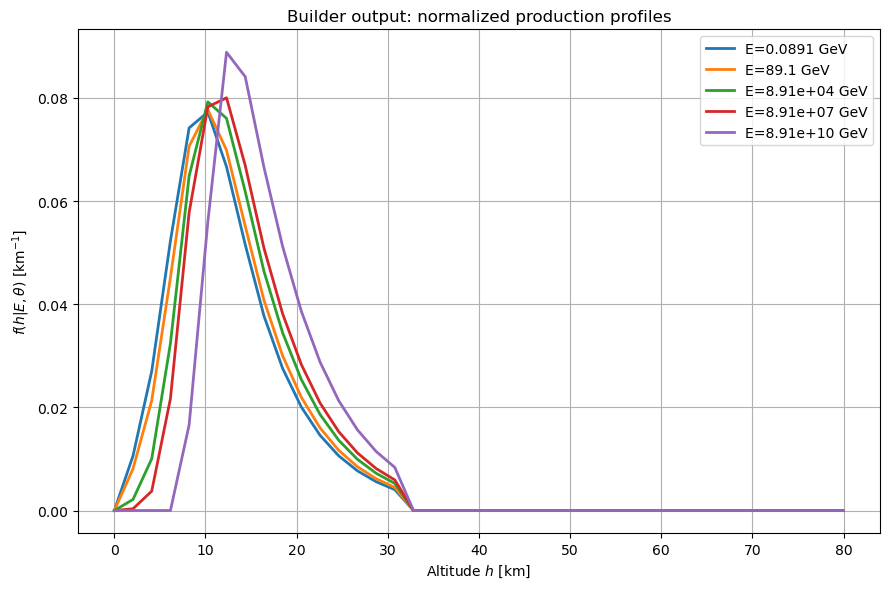

PASSED: plot_builder_profile_for_selected_energies()


In [21]:
run_notebook_call('plot_builder_profile_for_selected_energies()', lambda: TEST_MODULE.plot_builder_profile_for_selected_energies())


## Plot: `plot_builder_phi_Eh_for_selected_energies()`

**What is checked:** Builder phi eh for selected energies behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_builder_phi_Eh_for_selected_energies()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_builder_phi_Eh_for_selected_energies_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_builder_phi_Eh_for_selected_energies() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test9_builder\plot_builder_phi_Eh_for_selected_energies_figure_001.png


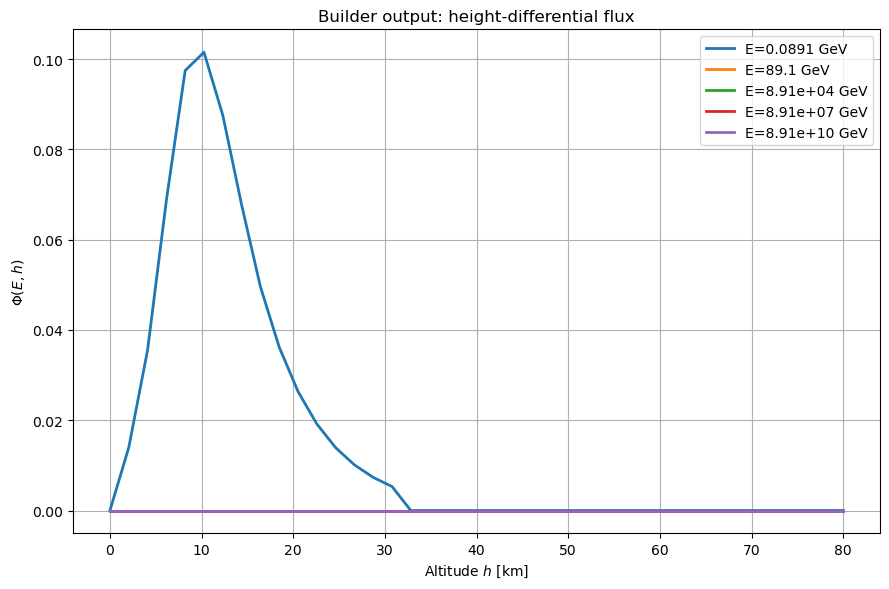

PASSED: plot_builder_phi_Eh_for_selected_energies()


In [22]:
run_notebook_call('plot_builder_phi_Eh_for_selected_energies()', lambda: TEST_MODULE.plot_builder_phi_Eh_for_selected_energies())


## Plot: `plot_builder_flux_reconstruction()`

**What is checked:** Builder flux reconstruction behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_builder_flux_reconstruction()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_builder_flux_reconstruction_figure_001.png`
- `plot_builder_flux_reconstruction_figure_002.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_builder_flux_reconstruction() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test9_builder\plot_builder_flux_reconstruction_figure_001.png


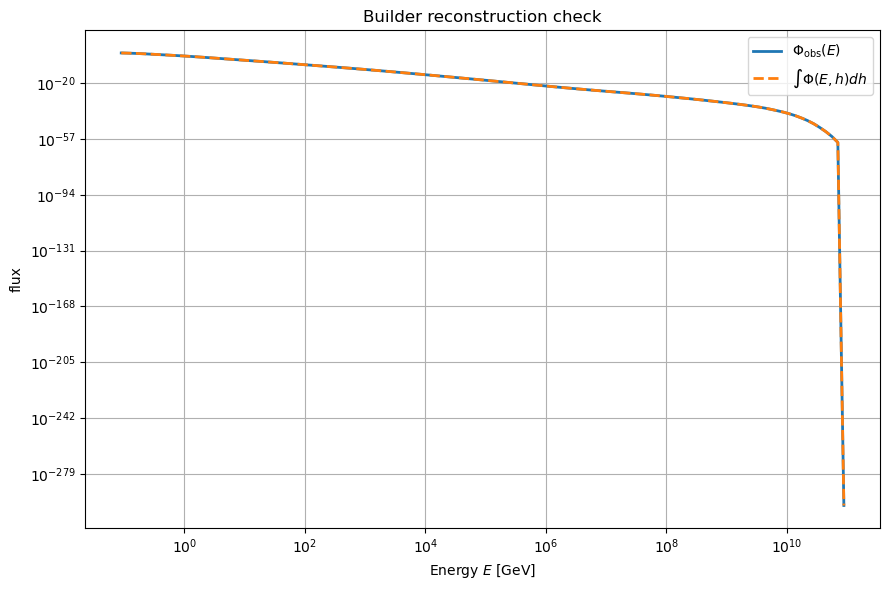

Saved plot: V:\output\test\mceq\test9_builder\plot_builder_flux_reconstruction_figure_002.png


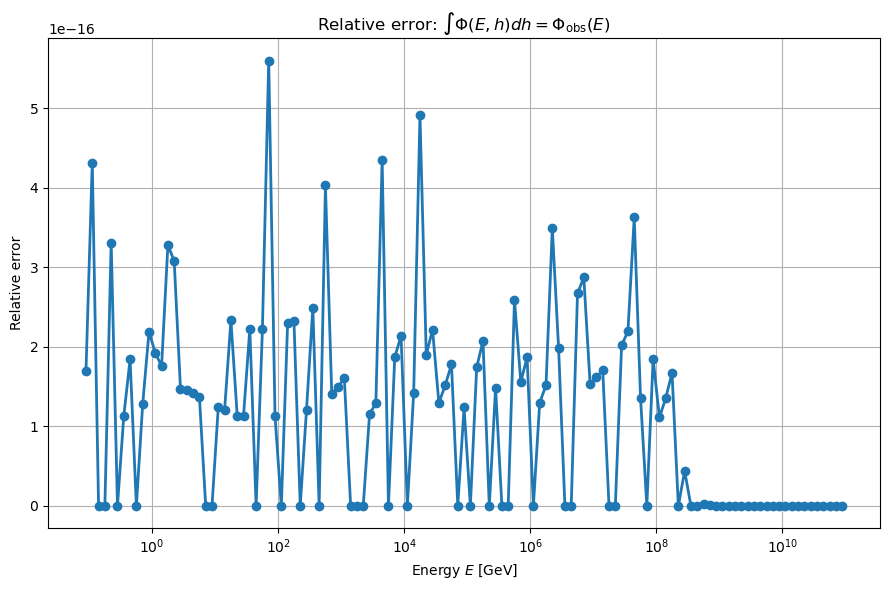

PASSED: plot_builder_flux_reconstruction()


In [23]:
run_notebook_call('plot_builder_flux_reconstruction()', lambda: TEST_MODULE.plot_builder_flux_reconstruction())
